In [1]:
import math
import numpy as np 
import matplotlib.pyplot as plt 

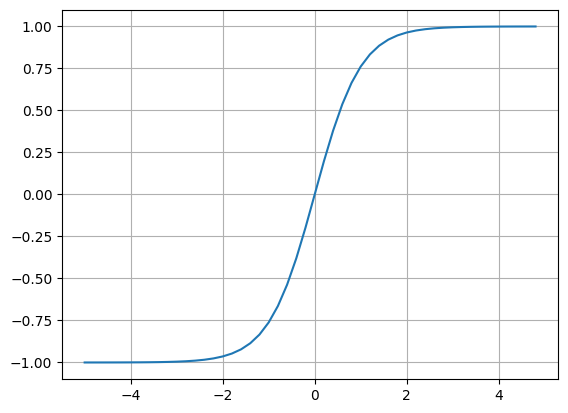

In [ ]:
# Plot Tanh activation function over a range of inputs 
# The inputs gets squashed at the y-coordinate. But why do we do this? 
# A neuron calculates its output by multiplying inputs by weights and adding them together (w1x1 + w2x2 + ... + b)
# To prevent the outputs from increasing exponentially, we need to normalize or rescale the results using an activation function
# to prevent what is called exploding gradients problem. 

# The activation function also helps us to mimic the mechanism of a biological neuron. 
# A biological neuron doesn't just pass electrical signals linearly. They accumulate a charge, and once it hits a certain threshold, they fire a pulse 

# Similar to a biological neuron, activation functions turns raw continuous mathematical score into a structured "intensity" or "decision"
# ----> Near 1.0 : This feature is strongly present/active 
# ----> Near -1.0: This feature is strongly absent/inactive 
# ----> Near 0.0:  This feature is neural/irrelevant 

# Bacause activation functions like tanh curve and bend, they introduce non-linearity. 
# This curvature allows the network to learn incredible complex, bending decision boundaries making it possible for it to recognize
# intricate patterns like human faces, languague structures, or objects in images 

# So that tanh fucntion caps high positive numbers at 1.0 
# And it caps very negative numbers at -1.0 
# Everything else stays inbetween 

plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [5]:
# The Value class 
class Value: 
    def __init__(self, data, _children=(), _op='', label=""):
        self.data = data 
        self.grad = 0.0 
        self._prev = set(_children)
        self._op = _op 
        self.label = label 
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out 

    def __mul__(self, other): 
        out = Value(self.data * other.data, (self, other), "*")
        return out  

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [6]:
# A simple 2-dimensional neuron 

# inputs 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights 
w1 = Value(-3.0, label='w1')
w2 = Value(-1.0, label='w2')

# bias of the neuron 
b = Value(6.7, label='b')

# x1*w1 + x2w2 + b 
x1w1 = x1 * w1; x1w1.label = "x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"

n = x1w1x2w2 + b; n.label = 'n'

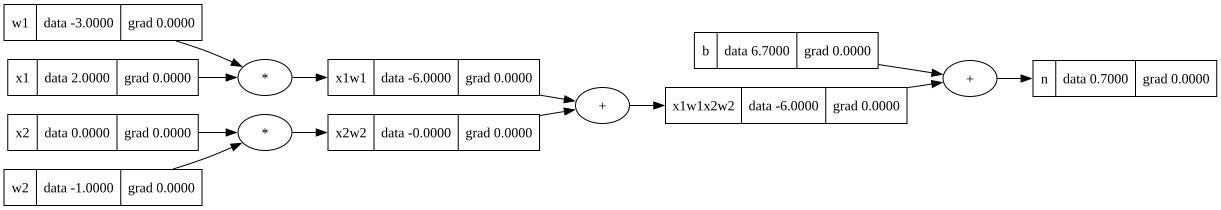

In [7]:
draw_dot(n)